# PySAM: Single Location & Geospatial

Run NREL's System Advisor Model (via [PySAM](https://nrel-pysam.readthedocs.io/))
through `pvdeg` for a single site and across a grid of locations.

Every example here uses weather data bundled with the repository, so the notebook
runs fully offline with no API key or network access required.

In [1]:
import os
import json

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import pvdeg
from pvdeg import DATA_DIR, TEST_DATA_DIR

## About PySAM

`pvdeg.pysam.pysam` wraps a PySAM performance model (here `pvsamv1`) and returns its
full output dictionary. You supply a weather `DataFrame` and a `meta` dict — exactly
what `pvdeg.weather` produces — plus a model and a named default configuration.

See the [SAM inputs reference](https://nrel-pysam.readthedocs.io/en/main/inputs-from-sam.html)
for the available configurations.

## Single location

Load a cached NSRDB weather file for Miami, FL that ships with the repo and run the
model for that one site.

In [2]:
# Cached NSRDB weather for Miami, FL, shipped with the pvdeg package -- fully
# offline, and resolves from a pip install as well as a repo clone.
data_dir = DATA_DIR

weather_miami = pd.read_csv(
    os.path.join(data_dir, "psm4_miami.csv"), index_col=0, parse_dates=True
)
with open(os.path.join(data_dir, "meta_miami.json")) as f:
    meta_miami = json.load(f)

In [3]:
results = pvdeg.pysam.pysam(
    weather_df=weather_miami,
    meta=meta_miami,
    pv_model="pvsamv1",
    pv_model_default="FlatPlatePVCommercial",
)

In [4]:
results["annual_energy"]

966537.7239838529

## Geospatial

`pvdeg` can map a function across many locations at once. Here we run PySAM over a
small grid of sites in Summit County, Colorado, using weather and metadata bundled
with the repo (`tests/data`).

In [5]:
GEO_META = pd.read_csv(os.path.join(TEST_DATA_DIR, "summit-meta.csv"), index_col=0)
GEO_WEATHER = xr.open_dataset(os.path.join(TEST_DATA_DIR, "summit-weather.nc"))

### A PySAM wrapper for geospatial data

`pvdeg.geospatial.analysis` calls a function once per location. The bundled weather
is half-hourly (17520 steps) but PySAM expects hourly data (8760 steps), so the
wrapper below resamples to hourly, drops the helper `gid` column, and returns just
the scalar we want to map — `annual_energy`.

In [6]:
# this is just a wrapper to grab the result we want
def pysam_annual_energy(
    weather_df, meta, pv_model="pvsamv1", pv_model_default="FlatPlatePVCommercial"
):
    # Drop the gid column if present (added by geospatial conversion)
    weather_df = weather_df.drop(columns=["gid"])

    # Resample half-hourly data to hourly (PySAM expects hourly)
    weather_df = weather_df.resample("h").mean()

    results = pvdeg.pysam.pysam(
        weather_df=weather_df,
        meta=meta,
        pv_model=pv_model,
        pv_model_default=pv_model_default,
    )

    return results["annual_energy"]

In [ ]:
# PySAM runs one full pvsamv1 simulation per location (~10 s each), so use a small
# subset. Keep this well under the 60 s per-cell timeout enforced by the testbook CI
# (tutorials/../scripts/run_all_testbook.py) — a handful of sites is plenty to demo.
subset_gids = GEO_META.index[:3]
GEO_META_SUB = GEO_META.loc[subset_gids]

# Chunk along 'gid' (one location per task) so the sites run in parallel instead of
# serially. 'time' is kept whole because each location needs its full timeseries.
GEO_WEATHER_SUB = GEO_WEATHER.sel(gid=subset_gids).chunk({"gid": 1, "time": -1})

# A scalar result is stored under the wrapper function's name, so the output template
# (which inherits the 'gid' chunking from the weather) must use that same key.
template = pvdeg.geospatial.output_template(
    ds_gids=GEO_WEATHER_SUB,
    shapes={
        "pysam_annual_energy": ("gid",),
    },
)

geo_res = pvdeg.geospatial.analysis(
    weather_ds=GEO_WEATHER_SUB,
    meta_df=GEO_META_SUB,
    func=pysam_annual_energy,
    template=template,
)

D:\repos\public\PVDegradationTools\pvdeg\utilities.py:1570: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  stacked = ds_gids.drop(["gid"])


In [8]:
geo_res

<xarray.Dataset> Size: 232B
Dimensions:              (latitude: 4, longitude: 5)
Coordinates:
  * latitude             (latitude) float64 32B 39.41 39.69 39.81 39.89
  * longitude            (longitude) float64 40B -106.4 -106.3 ... -106.2 -106.1
Data variables:
    pysam_annual_energy  (latitude, longitude) float64 160B nan nan ... nan nan

### Map the results

Each site's modeled annual energy, plotted at its location.

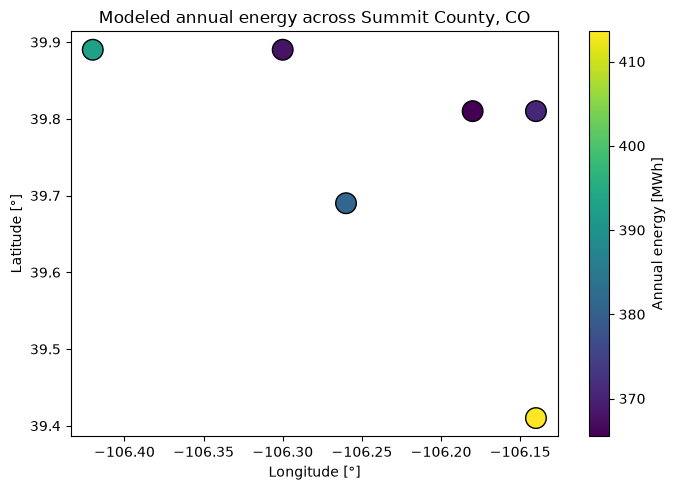

In [9]:
# analysis expands the results onto a (latitude, longitude) grid; keep the sites we ran.
sites = geo_res["pysam_annual_energy"].to_dataframe().dropna().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    sites["longitude"],
    sites["latitude"],
    c=sites["pysam_annual_energy"] / 1e3,
    s=220,
    cmap="viridis",
    edgecolor="k",
)
ax.set_xlabel("Longitude [\u00b0]")
ax.set_ylabel("Latitude [\u00b0]")
ax.set_title("Modeled annual energy across Summit County, CO")
fig.colorbar(sc, ax=ax, label="Annual energy [MWh]")
fig.tight_layout()
plt.show()